# MTNG hydrostatic mass bias — corrected pipeline (v2)

Replacement for the "Finding hydrostatic mass of halos" section onwards of the
original notebook. The Y–M half is unchanged and is not reproduced here.

All the physics lives in the importable package `mtng_hse/`, so it can be unit
tested and called from a search loop. This notebook is a thin driver plus the
figures.

## What changed, and why

| # | Change | Effect |
|---|--------|--------|
| 1 | **Bias sign.** `b = 1 − M_HSE/M_200c` (literature: `M_HSE = (1−b)M_true`). Was `M_HSE/M_true − 1`. | `b` is now positive for the usual under-estimate. Prevents sign errors in fitted coefficients. |
| 2 | **No in-place scaling.** `load_snapshot()` returns fresh arrays. | Re-running a cell can no longer double-apply `neProf *= rho_scaling`. |
| 3 | **Profiles fitted at shell centres**, not outer bin edges. | ~0.5 % systematic removed from `M_HSE`. |
| 4 | **Apertures specified by radius**, interpolated, not by index 101. | `M_gas(<R200c)` was overestimated by 1.1 %; concentrations were inconsistent. |
| 5 | **Analytic gNFW log-slope**, not `np.gradient` of the fitted curve. | Removes a discretisation error; also gives the slope *uncertainty*. |
| 6 | **Everything evaluated at exactly `r/R200c = 1`.** | Previously `ρ` was taken at 0.993 and `r` at 1.011 inside the same expression. |
| 7 | **`P` from the data, slope from the fit** (configurable). | The parametric model now only supplies the derivative, which is all it is needed for. |
| 8 | **Fit range restricted to 0.1–2.0 R200c** (configurable). | Stops the AGN-shaped core driving the outer slope that `M_HSE` depends on. |
| 9 | **Fit quality recorded** (`gnfw_rms_resid`) and used as a cut *and* a feature. | Poor gNFW fit ⇒ disturbed halo ⇒ more non-thermal support. |
| 10 | **Model-free local slope** computed alongside the gNFW slope. | Their difference is the model systematic, measured rather than assumed. |
| 11 | **`β`, `x_c` demoted to diagnostics**; the log-slope and its error are the features. | `corr(ln x_c, β) ≈ 0.98`. Feeding both to a regressor feeds a degeneracy. |
| 12 | **`M200c` removed from the predictor set.** | See §6 — this is the change that matters most for the final result. |

In [5]:
import os, sys, subprocess
import numpy as np
import matplotlib.pyplot as plt

os.chdir("..")

sys.path.insert(0, os.path.abspath("."))     # repo root containing mtng_hse/

from mtng_hse import config as C
from mtng_hse.data import load_snapshot, build_table
from mtng_hse.gnfw import fit_gnfw, log_pressure, log_slope, local_log_slope
from mtng_hse.hse import hse_at_radius, hse_mass_cgs
from mtng_hse.profiles import aperture_value, cumulative_profile, interp_profile
from mtng_hse.features import REGISTRY, predictors, diagnostics

plt.rcParams.update({"figure.figsize": (6, 4), "font.size": 12,
                     "axes.grid": True, "grid.alpha": 0.3,
                     "grid.linestyle": "--"})

DATA_DIR = "/Users/chase/glxy_mass/MTNG_data"     # <-- edit
SNAPSHOT = "z=0.0"
print("fit range      :", C.FIT_RANGE)
print("mass cut       :", f"{C.MASS_CUT*1e10:.1e} Msun/h")
print("P_th / P_e     :", f"{C.PTH_OVER_PE:.4f}")

fit range      : (0.1, 2.0)
mass cut       : 1.0e+14 Msun/h
P_th / P_e     : 1.9318


## 0. Gate: the validation suite must pass first

Tier 1 checks the algebra, the unit chain and the sign convention against
synthetic halos whose true mass is known in closed form. If any Tier 1 test
fails, nothing below is trustworthy — fix that first.

Tier 2 prints the systematics you should quote in the paper, including the
**fit-induced bias floor**: how much apparent `b` the fitting procedure alone
produces for a halo that is in perfect hydrostatic equilibrium by construction.
No discovered relation should be interpreted below that floor.

In [6]:
r = subprocess.run([sys.executable, "tests/test_pipeline.py"],
                   capture_output=True, text=True)
print(r.stdout[-4000:])
assert r.returncode == 0, "validation suite failed — stop here"

  implied kT        = 5.00 keV (input 5.00 keV)
  [PASS] Temperature round-trip P/rho -> kT
         kT = 6.500000 keV (expected 6.500000)
  [PASS] Bias sign convention b = 1 - M_HSE/M_true
         M_true inflated 25% -> b = +0.2000 (expect +0.2000)
  [PASS] Algebraic identity reproduces pipeline b
         pipeline +0.00007988  identity +0.00007988  diff +0.00e+00
  [PASS] Analytic slope vs np.gradient
         |difference| at R200c = 6.86e-05  (analytic -3.1909)
         max |difference| over grid = 3.19e-02
  [PASS] cumulative_profile is pure (idempotent loading)
         input array unchanged after two calls

TIER 2 -- quantified systematics (report these numbers)
  [PASS] gNFW fitter recovers known parameters
         P0  3.0000e-11 vs 3.0000e-11   (3.7e-15)
         xc  0.4500     vs 0.4500       (3.6e-15)
         beta 4.2000    vs 4.2000       (1.8e-15)
         RMS ln-residual = 2.97e-15
  [PASS] Fit-induced bias floor (halo in exact HSE)
         ln P scatter 0.00 -> b = +0.

## 1. Load

`load_snapshot` applies the unit scalings to copies. Running this cell twice
gives identical arrays, which was not true before.

In [7]:
snap = load_snapshot(DATA_DIR, SNAPSHOT, redshift=0.0)
print(f"{len(snap)} halos in {SNAPSHOT}")
print(f"M200c range: {snap.m200.min()*C.TNG_TO_MSUN:.2e} – "
      f"{snap.m200.max()*C.TNG_TO_MSUN:.2e} Msun")

# idempotency: reloading must not change anything
snap2 = load_snapshot(DATA_DIR, SNAPSHOT, redshift=0.0)
assert np.array_equal(snap.P_e, snap2.P_e), "loader is not pure!"
print("loader is idempotent")

37371 halos in z=0.0
M200c range: 1.48e+13 – 2.25e+15 Msun
loader is idempotent


## 2. Unit canary

`kT = μ m_p P/ρ` at R200c must land in a few keV for 10^14–10^15 M⊙ clusters,
and `f_gas` near the cosmic value. A wrong power of `h`, or a missing
`(kpc/Mpc)²`, shows up here as a number that is orders of magnitude off —
whereas inside a fitted scaling relation it would be quietly absorbed into the
amplitude and never noticed.

In [8]:
sel = np.where(snap.m200 > C.MASS_CUT)[0]
rng = np.random.default_rng(0)
probe = rng.choice(sel, size=min(200, len(sel)), replace=False)

rows = [hse_at_radius(snap.P_e[i], snap.rho_gas[i], snap.r200[i], snap.m200[i])
        for i in probe]
good = [r for r in rows if r.ok]

kT = np.array([r.kT_keV for r in good])
bb = np.array([r.bias   for r in good])
ss = np.array([r.slope_fit for r in good])

for name, v, key in [("kT(R200c) [keV]", kT, "kT_R200_keV"),
                     ("bias b",          bb, "bias"),
                     ("dlnP/dlnr(R200c)", ss, "slope_R200")]:
    lo, hi = C.SANITY[key]
    frac = np.mean((v > lo) & (v < hi))
    flag = "OK " if frac > 0.9 else "!! "
    print(f"{flag}{name:<20} median {np.median(v):+8.3f}   "
          f"16–84% [{np.percentile(v,16):+.3f}, {np.percentile(v,84):+.3f}]   "
          f"{frac:.0%} inside {lo, hi}")

OK kT(R200c) [keV]      median   +1.000   16–84% [+0.813, +1.468]   100% inside (0.5, 12.0)
OK bias b               median   +0.178   16–84% [+0.074, +0.276]   98% inside (-0.15, 0.55)
OK dlnP/dlnr(R200c)     median   -3.844   16–84% [-4.289, -3.355]   100% inside (-6.0, -1.5)


## 3. Build the per-halo table

One row per halo above the mass cut: the target `bias`, every registered
feature, and the fit diagnostics. Failed fits are flagged rather than dropped,
so the failure rate stays visible.

In [9]:
tab = build_table(snap, mass_cut=C.MASS_CUT, r_eval=1.0, progress=True)

ok = tab["ok"] > 0.5
qual = ok & (tab["gnfw_rms_resid"] < C.MAX_LOG_RESID)
print(f"\n{ok.sum()} converged / {len(ok)} above cut")
print(f"{qual.sum()} also pass the fit-quality cut "
      f"(rms ln-resid < {C.MAX_LOG_RESID})")
print(f"\nb: median {np.median(tab['bias'][qual]):+.3f}, "
      f"mean {np.mean(tab['bias'][qual]):+.3f}, "
      f"scatter {np.std(tab['bias'][qual]):.3f}")

2333 halos above M200c = 1e+04 (1e10 Msun/h)
  HSE 0/2333
  HSE 250/2333
  HSE 500/2333
  HSE 750/2333
  HSE 1000/2333
  HSE 1250/2333
  HSE 1500/2333
  HSE 1750/2333
  HSE 2000/2333
  HSE 2250/2333
gNFW fit + HSE succeeded for 97.8% of halos

2282 converged / 2333 above cut
2282 also pass the fit-quality cut (rms ln-resid < 0.25)

b: median +0.186, mean +0.172, scatter 0.117


## 4. The bias

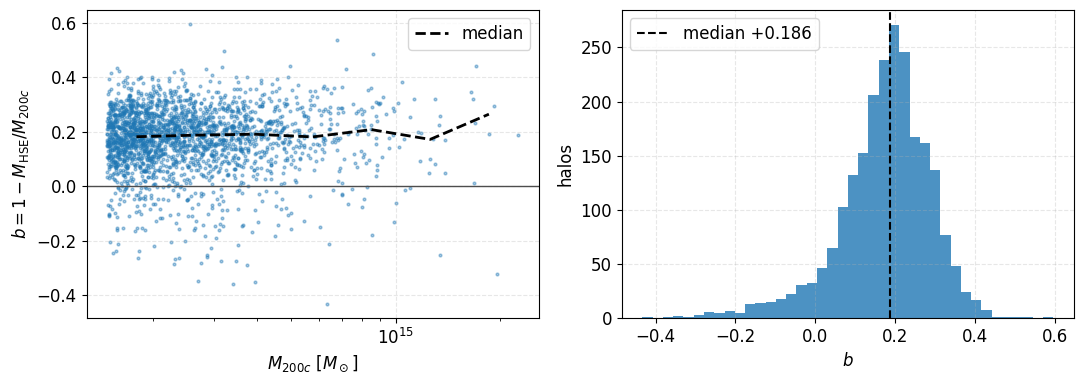

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

m = tab["M200c"][qual]
b = tab["bias"][qual]

ax[0].scatter(m, b, s=4, alpha=0.4)
edges = np.logspace(np.log10(m.min()), np.log10(m.max()), 8)
cen = np.sqrt(edges[:-1] * edges[1:])
med = [np.median(b[(m >= lo) & (m < hi)]) if ((m >= lo) & (m < hi)).sum() > 5
       else np.nan for lo, hi in zip(edges[:-1], edges[1:])]
ax[0].plot(cen, med, "k--", lw=2, label="median")
ax[0].axhline(0, color="0.3", lw=1)
ax[0].set_xscale("log")
ax[0].set_xlabel(r"$M_{200c}\ [M_\odot]$")
ax[0].set_ylabel(r"$b = 1 - M_{\rm HSE}/M_{200c}$")
ax[0].legend()

ax[1].hist(b, bins=40, alpha=0.8)
ax[1].axvline(np.median(b), color="k", ls="--",
              label=f"median {np.median(b):+.3f}")
ax[1].set_xlabel(r"$b$"); ax[1].set_ylabel("halos"); ax[1].legend()
plt.tight_layout(); plt.show()

## 5. Profile fits

Sanity-check a handful of fits by eye. The shaded band is the fit range that
actually constrains the slope at R200c.

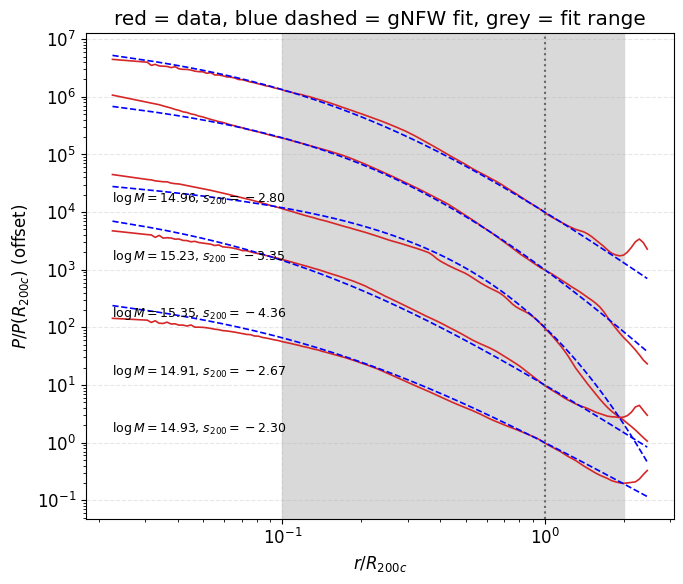

In [11]:
ids = np.where(qual)[0][:5]
fig, ax = plt.subplots(figsize=(7, 6))
for j, k in enumerate(ids):
    i = int(tab["halo_id"][k])
    P = snap.P_e[i] * C.PTH_OVER_PE
    f = fit_gnfw(C.R_EFF, snap.P_e[i])
    off = 10.0 ** j
    ax.loglog(C.R_EFF, P / P[np.argmin(abs(C.R_EFF - 1))] * off,
              color="C3", lw=1.2)
    ax.loglog(C.R_EFF,
              np.exp(f.log_pressure_at(C.R_EFF) - f.log_pressure_at(1.0)) * off,
              "b--", lw=1.2)
    ax.text(C.R_EFF[0], off * 1.5,
            rf"$\log M={np.log10(tab['M200c'][k]):.2f}$, "
            rf"$s_{{200}}={f.slope_at(1.0):+.2f}$", fontsize=9)
ax.axvspan(*C.FIT_RANGE, color="0.85", zorder=0)
ax.axvline(1.0, color="0.4", ls=":")
ax.set_xlabel(r"$r/R_{200c}$")
ax.set_ylabel(r"$P/P(R_{200c})$ (offset)")
ax.set_title("red = data, blue dashed = gNFW fit, grey = fit range")
plt.tight_layout(); plt.show()

## 6. The decomposition — why this is not a black box

At `r = R200c` the hydrostatic mass is *exactly*

$$M_{\rm HSE} = -\frac{R_{200c}\,P_{\rm th}}{G\,\rho_{\rm gas}}\,
\frac{d\ln P}{d\ln r}\Big|_{R_{200c}}
\quad\Longrightarrow\quad
1-b \;\propto\; \frac{k T_{200}}{\mu m_p\, GM/R}\;\times\;(-s_{200}).$$

So the bias is *how hot the gas is at R200c relative to virial*, times *how
steeply the pressure is falling there*. Nothing else. The modelling problem is
to predict those two factors from observables — a far better-posed search than
regressing `b` on nine loosely-motivated columns.

The left panel below should be a straight line with essentially zero scatter.
If it is not, there is a bug, not physics.

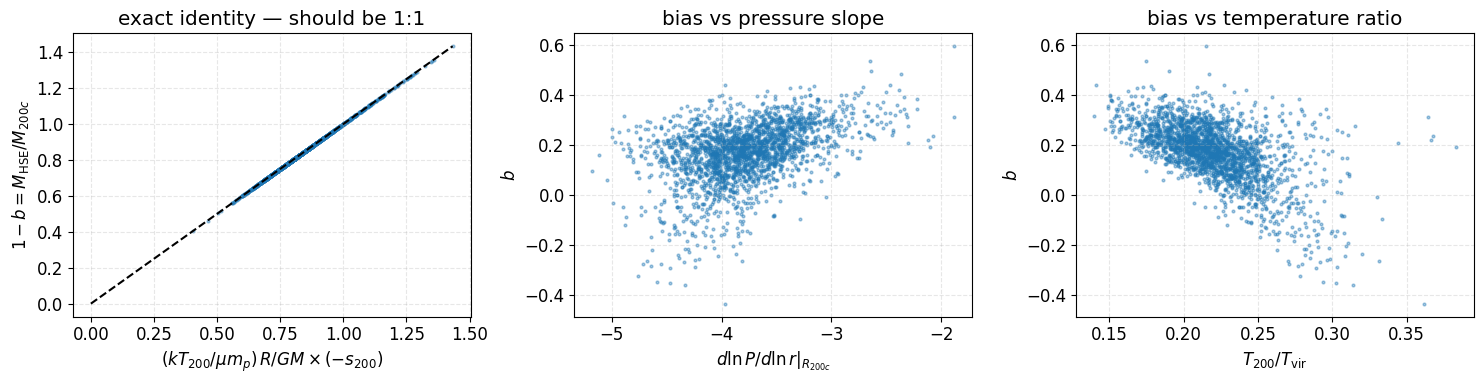

identity residual: mean +7.83e-18, max |resid| 6.66e-16


In [12]:
kT_erg = tab["kT_R200"][qual] * C.KEV_ERG
R_cm   = tab["R200c"][qual] * C.TNG_TO_CM
M_g    = tab["M200c"][qual] * C.MSUN_G
T_over_Tvir = kT_erg * R_cm / (C.MU * C.PROTON_G * C.G_CGS * M_g)
predicted = T_over_Tvir * (-tab["slope_R200"][qual])

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].scatter(predicted, 1 - tab["bias"][qual], s=4, alpha=0.4)
lim = [min(predicted.min(), 0), max(predicted.max(), 1.2)]
ax[0].plot(lim, lim, "k--", lw=1.5)
ax[0].set_xlabel(r"$(kT_{200}/\mu m_p)\,R/GM \times (-s_{200})$")
ax[0].set_ylabel(r"$1-b = M_{\rm HSE}/M_{200c}$")
ax[0].set_title("exact identity — should be 1:1")

ax[1].scatter(tab["slope_R200"][qual], tab["bias"][qual], s=4, alpha=0.4)
ax[1].set_xlabel(r"$d\ln P/d\ln r|_{R_{200c}}$"); ax[1].set_ylabel(r"$b$")
ax[1].set_title("bias vs pressure slope")

ax[2].scatter(T_over_Tvir, tab["bias"][qual], s=4, alpha=0.4)
ax[2].set_xlabel(r"$T_{200}/T_{\rm vir}$"); ax[2].set_ylabel(r"$b$")
ax[2].set_title("bias vs temperature ratio")
plt.tight_layout(); plt.show()

resid = (1 - tab["bias"][qual]) - predicted
print(f"identity residual: mean {np.mean(resid):+.2e}, "
      f"max |resid| {np.max(np.abs(resid)):.2e}")

## 7. How much did the fixes move `b`?

Reproduces the original conventions (fit against outer bin edges, `np.gradient`
on the fitted curve, pressure from the fit, everything indexed at 101, full
radial range) and differences them against the corrected pipeline. This is the
number to quote when someone asks whether the fixes mattered.

old convention : median b = +0.2092
new convention : median b = +0.2047
shift          : -0.0139 (scatter 0.1639)


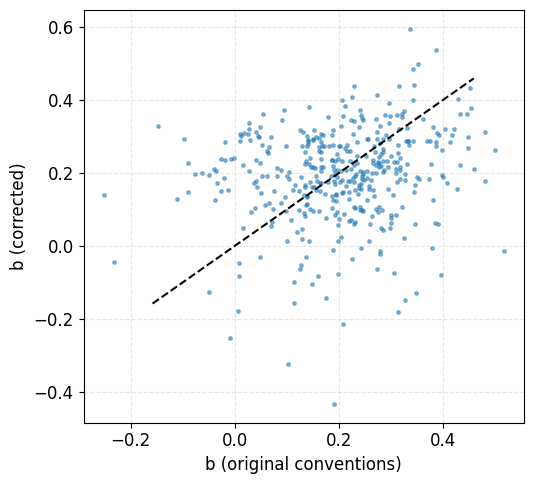

In [13]:
def bias_old_convention(i):
    r_edge = C.RBIN_EDGES[1:]
    P = snap.P_e[i] * C.PTH_OVER_PE
    P200 = P[101]                                # the old R200_BIN_IDX
    lnP = np.log(P / P200)
    f = fit_gnfw(r_edge, P, fit_range=(C.R_MIN_GRID, C.R_MAX_GRID))
    if not f.converged:
        return np.nan
    ln_fit = f.log_pressure_at(r_edge)
    dlnP_dr = np.gradient(ln_fit, r_edge) / (snap.r200[i] * C.TNG_TO_CM)
    rho = snap.rho_gas[i]
    pref = -((r_edge * snap.r200[i] * C.TNG_TO_CM) ** 2) / (C.G_CGS * rho)
    Mprof = pref * dlnP_dr * np.exp(ln_fit)
    m_hse = Mprof[101] / C.MSUN_G
    return 1.0 - m_hse / (snap.m200[i] * C.TNG_TO_MSUN)

idx = np.where(qual)[0][:400]
b_old = np.array([bias_old_convention(int(tab["halo_id"][k])) for k in idx])
b_new = tab["bias"][idx]
g = np.isfinite(b_old) & np.isfinite(b_new)

print(f"old convention : median b = {np.median(b_old[g]):+.4f}")
print(f"new convention : median b = {np.median(b_new[g]):+.4f}")
print(f"shift          : {np.median(b_new[g]-b_old[g]):+.4f} "
      f"(scatter {np.std(b_new[g]-b_old[g]):.4f})")

plt.figure(figsize=(5.5, 5))
plt.scatter(b_old[g], b_new[g], s=6, alpha=0.5)
lo, hi = np.percentile(np.r_[b_old[g], b_new[g]], [1, 99])
plt.plot([lo, hi], [lo, hi], "k--")
plt.xlabel("b (original conventions)"); plt.ylabel("b (corrected)")
plt.tight_layout(); plt.show()

## 8. Feature table for the search stage

Only `allowed_in_equation` features are exported as predictors. `M200c` is a
diagnostic: an observer measuring a cluster does not know it, so a formula
containing it cannot be applied. Using it as the leading RF feature — as the
original notebook did — both inflates the apparent skill and produces something
unusable.

In [14]:
print(f"{'feature':<20} {'observability':<12} {'allowed':<8} corr(b)")
print("-" * 58)
for name, feat in REGISTRY.items():
    if name not in tab:
        continue
    v = tab[name][qual]
    g = np.isfinite(v) & np.isfinite(tab["bias"][qual])
    c = np.corrcoef(v[g], tab["bias"][qual][g])[0, 1] if g.sum() > 10 else np.nan
    print(f"{name:<20} {feat.observability.value:<12} "
          f"{'yes' if feat.allowed_in_equation else 'DIAG':<8} {c:+.3f}")

cols = [c for c in predictors() if c in tab] + ["bias", "M200c"]
np.savez("halo_table_z0.npz", **{c: tab[c][qual] for c in cols})
print(f"\nsaved {qual.sum()} halos x {len(cols)} columns -> halo_table_z0.npz")

feature              observability allowed  corr(b)
----------------------------------------------------------
M_hse                DIRECT       yes      -0.224
slope_R200           FEASIBLE     yes      +0.429
kT_R200              FEASIBLE     yes      -0.215
slope_local_R200     FEASIBLE     yes      +0.360
c_Y_0p50             DIRECT       yes      +0.265
c_Y_0p15             DIRECT       yes      +0.126
c_gas_0p50           DIRECT       yes      +0.120
c_gas_0p15           DIRECT       yes      +0.060
Y_ratio_0p65         DIRECT       yes      +0.287
logit_c_Y_0p50       DIRECT       yes      +0.263
Mstar_over_Mgas      DIRECT       yes      +0.162
f_gas_hse            DIRECT       yes      +0.898
gnfw_rms_resid       FEASIBLE     yes      -0.182
M200c                SIM_ONLY     DIAG     +0.003
f_gas_true           SIM_ONLY     DIAG     -0.223

saved 2282 halos x 15 columns -> halo_table_z0.npz


## Next

`halo_table_z0.npz` is the input to the search stage. Before any equation
search runs:

1. Confirm Tier 1 passes and record the Tier 2 systematics — they set the floor
   below which a "discovery" is a fitting artefact.
2. Freeze the splits (see the plan document) and lock the evaluator.
3. Fit the L0 identity and the L1 physics ansatz; the search targets the
   *residual* to those, not `b` itself.